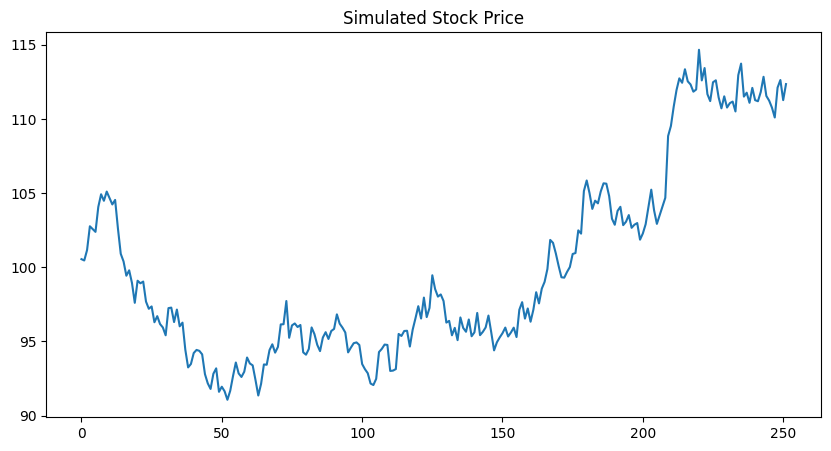

Mean daily log return: 0.00044241186491338075
Daily volatility: 0.009686287079873466
Annual Return: 0.11148778995817195
Annual Volatility: 0.15376504044553937
Sharpe Ratio: 0.7250529095243777


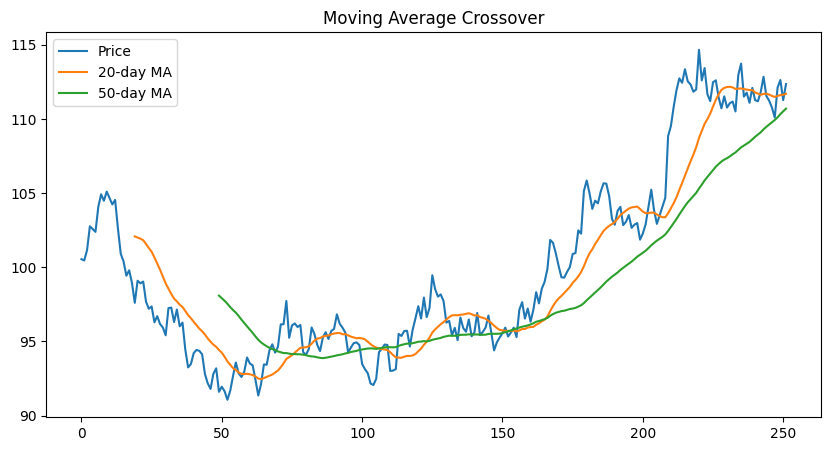

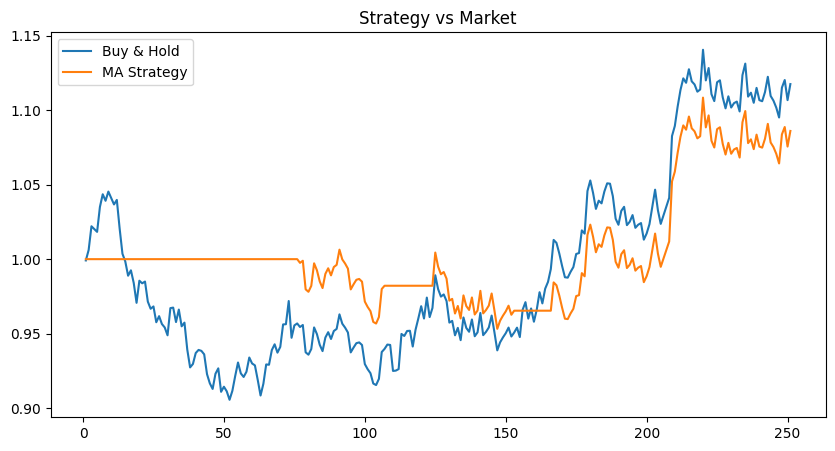

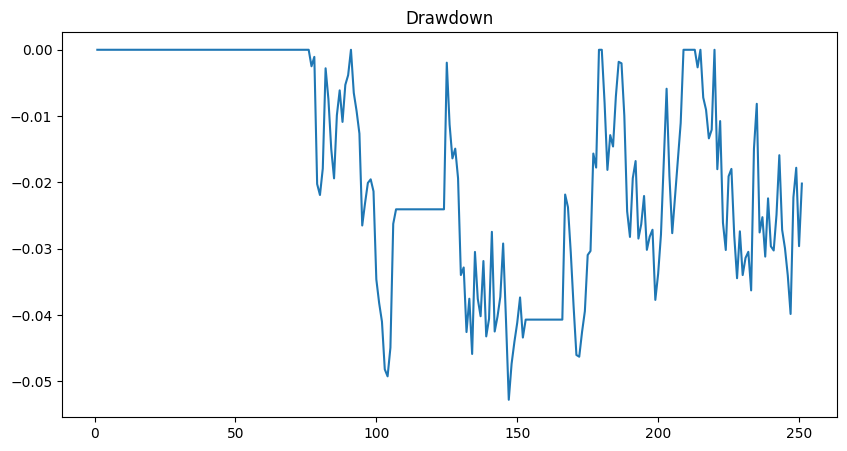

Max Drawdown: -0.052778484245604676


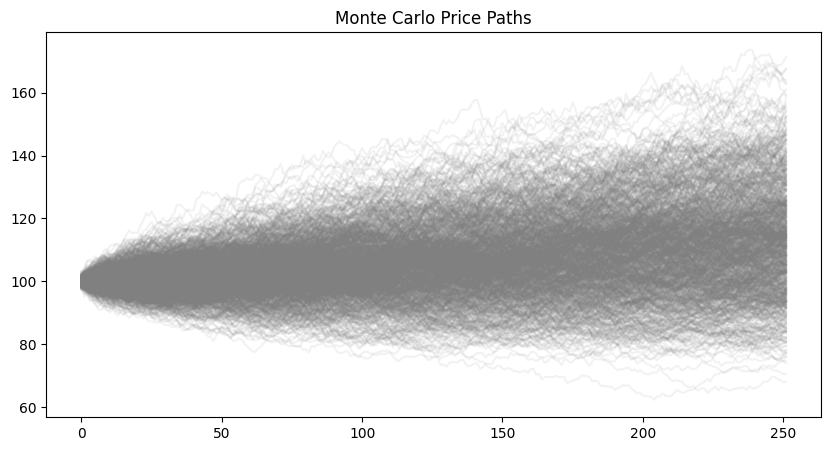

In [1]:
# Quantitative Finance in Python — Jupyter-Style Tutorial
# Author: You + ChatGPT
# How to use: Copy this into a Jupyter Notebook (.ipynb) or run cell-by-cell.

# =============================================================
# 0. What is Quantitative Finance?
# =============================================================
# Quant finance uses math, statistics, and programming to:
# - Model asset prices
# - Test trading strategies
# - Manage risk
# - Price derivatives

# This tutorial focuses on *practical* quant skills:
# data → analysis → strategy → backtest


In [2]:
# =============================================================
# 1. Setup & Core Libraries
# =============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)

# Optional but useful later:
# pip install yfinance scipy statsmodels

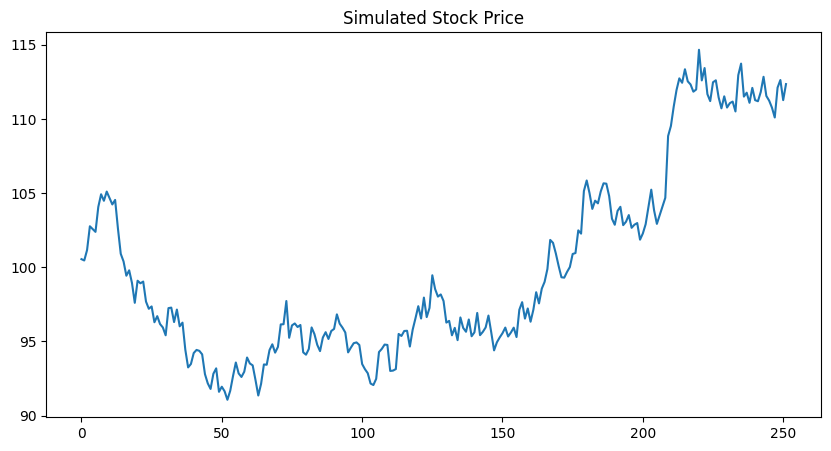

In [3]:
# =============================================================
# 2. Financial Time Series Basics
# =============================================================

# Create a fake price series (like a stock)
np.random.seed(42)
returns = np.random.normal(0.0005, 0.01, 252)
price = 100 * np.exp(np.cumsum(returns))

prices = pd.Series(price)
prices.plot(title="Simulated Stock Price")
plt.show()

# Key idea: prices are usually non-stationary

In [4]:
# =============================================================
# 3. Returns (the language of finance)
# =============================================================

# Simple returns
simple_returns = prices.pct_change().dropna()

# Log returns (preferred in quant finance)
log_returns = np.log(prices / prices.shift(1)).dropna()

print("Mean daily log return:", log_returns.mean())
print("Daily volatility:", log_returns.std())

Mean daily log return: 0.00044241186491338075
Daily volatility: 0.009686287079873466


In [5]:
# =============================================================
# 4. Risk & Performance Metrics
# =============================================================

# Annualization
trading_days = 252

annual_return = log_returns.mean() * trading_days
annual_vol = log_returns.std() * np.sqrt(trading_days)

# Sharpe Ratio (assuming 0% risk-free rate)
sharpe = annual_return / annual_vol

print("Annual Return:", annual_return)
print("Annual Volatility:", annual_vol)
print("Sharpe Ratio:", sharpe)

Annual Return: 0.11148778995817195
Annual Volatility: 0.15376504044553937
Sharpe Ratio: 0.7250529095243777


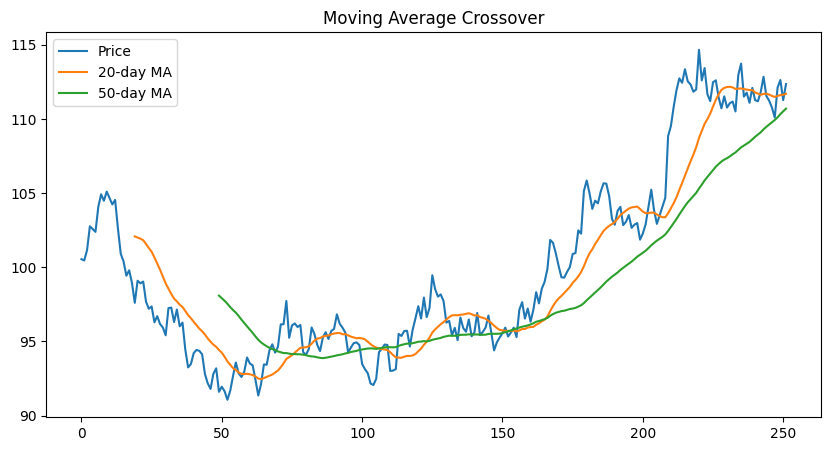

In [6]:
# =============================================================
# 5. Moving Averages (First Trading Signal)
# =============================================================

short_window = 20
long_window = 50

ma_short = prices.rolling(short_window).mean()
ma_long = prices.rolling(long_window).mean()

plt.plot(prices, label="Price")
plt.plot(ma_short, label="20-day MA")
plt.plot(ma_long, label="50-day MA")
plt.legend()
plt.title("Moving Average Crossover")
plt.show()

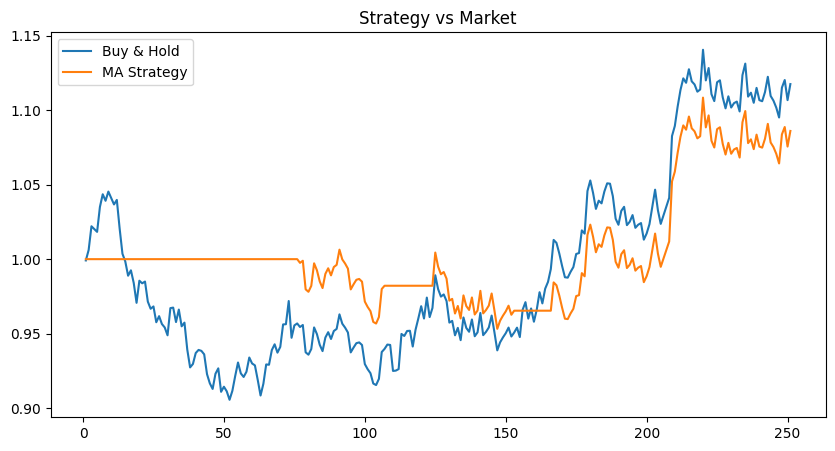

In [7]:
# =============================================================
# 6. Simple Trading Strategy
# =============================================================

# Signal: 1 = long, 0 = out of market
signal = (ma_short > ma_long).astype(int)

# Strategy returns
strategy_returns = signal.shift(1) * log_returns

# Compare performance
cum_market = log_returns.cumsum().apply(np.exp)
cum_strategy = strategy_returns.cumsum().apply(np.exp)

plt.plot(cum_market, label="Buy & Hold")
plt.plot(cum_strategy, label="MA Strategy")
plt.legend()
plt.title("Strategy vs Market")
plt.show()

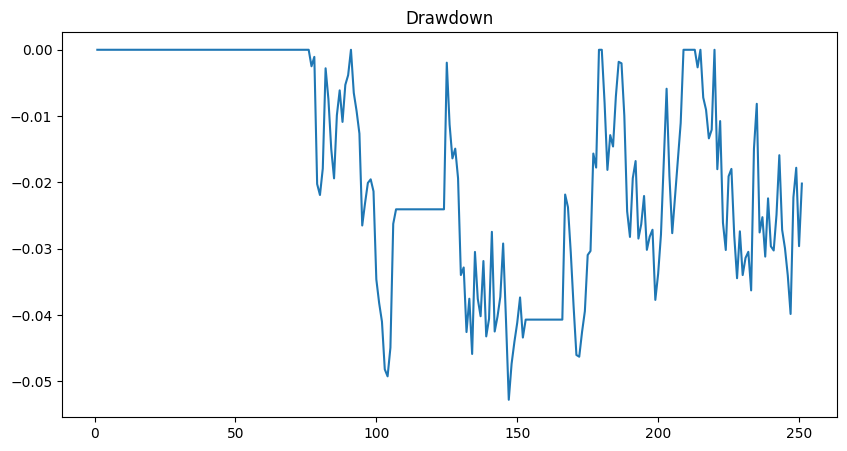

Max Drawdown: -0.052778484245604676


In [8]:
# =============================================================
# 7. Drawdowns (Risk You Actually Feel)
# =============================================================

wealth = cum_strategy
peak = wealth.cummax()
drawdown = (wealth - peak) / peak

drawdown.plot(title="Drawdown")
plt.show()

print("Max Drawdown:", drawdown.min())

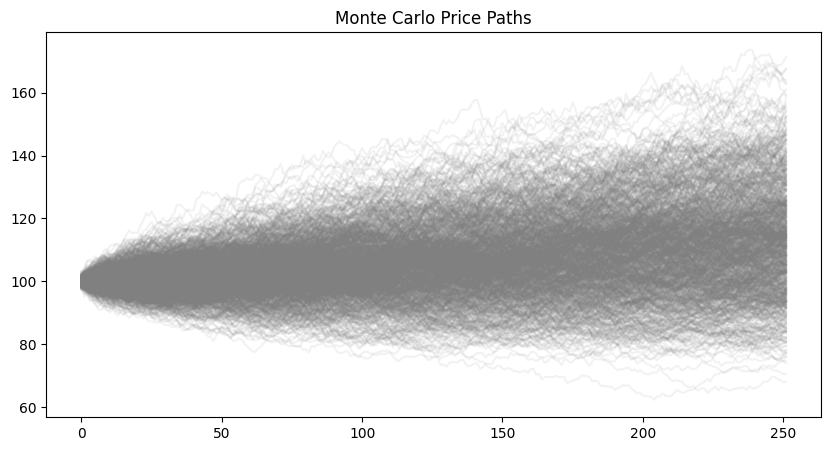

In [9]:
# =============================================================
# 8. Monte Carlo Simulation
# =============================================================

simulations = 1000
horizon = 252

mu = log_returns.mean()
sigma = log_returns.std()

paths = []
for _ in range(simulations):
    sim_returns = np.random.normal(mu, sigma, horizon)
    sim_price = 100 * np.exp(np.cumsum(sim_returns))
    paths.append(sim_price)

paths = np.array(paths)

plt.plot(paths.T, color='gray', alpha=0.1)
plt.title("Monte Carlo Price Paths")
plt.show()

In [10]:
# =============================================================
# 9. What You’ve Learned So Far
# =============================================================
# ✔ Time series & returns
# ✔ Risk metrics (volatility, Sharpe, drawdown)
# ✔ Strategy signals
# ✔ Backtesting basics
# ✔ Monte Carlo simulation


# =============================================================
# 10. Where to Go Next (Real Quant Stuff)
# =============================================================
# - Mean reversion strategies
# - Momentum & factor models
# - Portfolio optimization (Markowitz)
# - Statistical arbitrage
# - Options pricing (Black–Scholes)
# - Machine learning for finance

# Tell ChatGPT what you want next 👇
# "Teach me mean reversion"
# "Do portfolio optimization"
# "Use real stock data"